In [1]:
import os
if "KERAS_BACKEND" not in os.environ:
    os.environ["KERAS_BACKEND"] = "jax"
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import math
import random
RNG = np.random.default_rng(2023)
from scipy.stats import beta
from scipy.spatial.distance import cdist

import keras
import bayesflow as bf
from functools import partial

import numba as nb
from numba import cuda, float32, int32
from numba.cuda.random import create_xoroshiro128p_states, xoroshiro128p_uniform_float32, xoroshiro128p_normal_float32
import logging
numba_logger = logging.getLogger('numba')
numba_logger.setLevel(logging.WARNING)

import pandas as pd

SEED = 42
np.random.seed(SEED)
keras.utils.set_random_seed(SEED)
RNG = np.random.default_rng(SEED)
rng_states = create_xoroshiro128p_states(2000*2400, seed=SEED)

INFO:bayesflow:Using backend 'jax'


In [2]:
import importlib, sys, subprocess

print("=== Python ===")
print(sys.version)

print("\n=== Package Versions ===")
for pkg_name in ["keras", "bayesflow", "numpy", "pandas", "matplotlib", "seaborn", "numba", "jax", "jaxlib"]:
    try:
        mod = importlib.import_module(pkg_name)
        print(f"{pkg_name}: {getattr(mod, '__version__', 'unknown')}")
    except ImportError:
        print(f"{pkg_name}: NOT INSTALLED")

print("\n=== CUDA / GPU Info ===")
try:
    print(f"CUDA available: {cuda.is_available()}")
    if cuda.is_available():
        print(f"GPU: {cuda.get_current_device().name}")
except Exception as e:
    print(f"CUDA check failed: {e}")

=== Python ===
3.11.3 (main, Aug 13 2025, 16:49:22) [GCC 12.3.0]

=== Package Versions ===
keras: 3.11.3
bayesflow: 2.0.6
numpy: 1.26.4
pandas: 2.3.3
matplotlib: 3.10.6
seaborn: 0.13.2
numba: 0.62.1
jax: 0.4.28
jaxlib: 0.4.28

=== CUDA / GPU Info ===
CUDA available: True
GPU: b'NVIDIA H100 80GB HBM3'


## HCDM

In [3]:
@cuda.jit
def cuda_diffusion_trial_hcdm(rng_states, out_rt, out_resp, in_l, in_phi, in_a, in_zx, in_zy, in_ndt, dt, max_steps, num_threads):
    """Simulates a trial from the diffusion model."""
    
    thread_id = cuda.grid(1)

    if (thread_id < num_threads):
        l = in_l[thread_id]
        phi = in_phi[thread_id]
        a = in_a[thread_id]
        zx = in_zx[thread_id]
        zy = in_zy[thread_id]
        ndt = in_ndt[thread_id]

        n_steps = 0
        x = zx * a 
        y = zy * a

        x_target = a * math.cos(phi)
        y_target = a * math.sin(phi)

        V_x = x_target - x
        V_y = y_target - y

        magnitude = math.sqrt(V_x**2 + V_y**2)
        vx = l * (V_x / magnitude)
        vy = l * (V_y / magnitude)
        
        mu_x = vx * dt
        mu_y = vy * dt
        
        sigma = math.sqrt(dt)

        # Simulate a single DM path
        for n_steps in range(max_steps):
            # Generate random noise
            dx = mu_x + sigma * xoroshiro128p_normal_float32(rng_states, thread_id)
            dy = mu_y + sigma * xoroshiro128p_normal_float32(rng_states, thread_id)
            
            # Check if step would cross the boundary (y + dy <= 0)
            if y + dy <= 0:
                # Calculate exactly where we hit the boundary
                # We need to find t such that y + t * dy = 0
                # So t = -y / dy (assuming dy != 0)
                
                if abs(dy) > 1e-12:  # Avoid division by zero
                    t_boundary = -y / dy  # Fraction of step to reach boundary
                    
                    # Move to the boundary
                    x_boundary = x + t_boundary * dx
                    y_boundary = 0.0  # Exactly at boundary
                    
                    # Calculate remaining step after hitting boundary
                    dx_remaining = (1.0 - t_boundary) * dx
                    dy_remaining = (1.0 - t_boundary) * dy
                    
                    # Reflect the remaining step (flip y-component)
                    dx_reflected = dx_remaining
                    dy_reflected = -dy_remaining
                    
                    # Apply the reflected remaining step
                    x = x_boundary + dx_reflected
                    y = y_boundary + dy_reflected
                    
                else:
                    # If dy is essentially zero, just move horizontally
                    x += dx
                    # y stays the same (no vertical movement)
                    
            else:
                # Normal step - no boundary crossing
                x += dx
                y += dy
                    
            # Check if we've reached the circular boundary
            if x**2 + y**2 >= a**2:
                break
            
        rt = float(n_steps) * dt
        resp = math.atan2(y, x)
         
        out_rt[thread_id] = rt + ndt
        out_resp[thread_id] = resp


In [4]:
def diffusion_prior_hcdm(batch_info, rng=None):
    if rng is None:
        rng = np.random.default_rng()  # np.random，不是rng

    if isinstance(batch_info, tuple):
        batch_size = batch_info[0]
    elif isinstance(batch_info, dict):
        batch_size = batch_info["batch_size"]
    else:
        batch_size = batch_info  # assume int
        
    l = rng.uniform(0.5, 9, size = (batch_size, 4))
    a = rng.uniform(0.5, 9, size = batch_size)
        
    zx = rng.uniform(-0.7, 0.7, size = batch_size)
    zy = rng.uniform(0, 0.7, size = batch_size)

    ndt = rng.uniform(0.1, 2.5, size = batch_size)

 
    phi = rng.uniform(0, np.pi, size=(batch_size, 4)) 

    return {
        "l": l,
        "phi": phi,
        "a": a.reshape(batch_size, 1),
        "zx": zx.reshape(batch_size, 1),
        "zy": zy.reshape(batch_size, 1),
        "ndt": ndt.reshape(batch_size, 1),
    }



In [5]:
max_n = 200
THREADS_PER_BLOCK = 64 

def cuda_convert_matrix_to_hcdm(l, phi, a, zx, zy, ndt, batch_size, num_obs, con):
 
    total_threads = batch_size * num_obs
    
    # Convert one-hot condition matrix to condition indices 
    condition_ids = np.argmax(con, axis=-1)  # (batch_size, num_obs)
    
    # Compute flattened indices for batch and observation
    flat_index = np.arange(total_threads)
    i_indices = flat_index // num_obs  # dataset index
    k_indices = flat_index % num_obs   # observation index
    
    # Gather condition indices per observation
    cond_indices = condition_ids[i_indices, k_indices]
    
    # Vectorized lookup of parameters for each trial
    in_l = l[i_indices, cond_indices].astype(np.float32)
    in_phi = phi[i_indices, cond_indices].astype(np.float32)
    in_a = a[i_indices, 0].astype(np.float32)
    in_zx = zx[i_indices, 0].astype(np.float32)
    in_zy = zy[i_indices, 0].astype(np.float32)
    in_ndt = ndt[i_indices, 0].astype(np.float32)
    
    # Transfer to GPU device arrays
    return (
        cuda.to_device(in_l),
        cuda.to_device(in_phi),
        cuda.to_device(in_a),
        cuda.to_device(in_zx),
        cuda.to_device(in_zy),
        cuda.to_device(in_ndt),
    )


@cuda.jit
def kernel_convert_matrix_from_hcdm(out_rt, out_resp, out):
    idx = cuda.grid(1)
    total_threads = out_rt.size
    
    if idx < total_threads:
        i = idx // out.shape[1]  # batch index
        k = idx % out.shape[1]   # observation index
        
        out[i, k, 0] = out_rt[idx]
        out[i, k, 1] = out_resp[idx]

def cuda_convert_matrix_from_gpu_hcdm(out_rt, out_resp, batch_size, num_obs):
    # Allocate device output array
    out = cuda.device_array((batch_size, num_obs, 2), dtype=np.float32)
    total_threads = batch_size * num_obs
    blocks = (total_threads + THREADS_PER_BLOCK - 1) // THREADS_PER_BLOCK
    
    kernel_convert_matrix_from_hcdm[blocks, THREADS_PER_BLOCK](out_rt, out_resp, out)
    
    return out


def cuda_simulator_hcdm(l, phi, a, zx, zy, ndt, 
                   num_obs_per_condition, 
                   rng=None, *args):
    
    batch_size = l.shape[0]
    num_conditions = 4

    num_obs = int(np.sum(num_obs_per_condition))
    total_threads = int(batch_size * num_obs)
    
    con_labels = np.concatenate([
        np.full(count, i, dtype=int)
        for i, count in enumerate(num_obs_per_condition)
    ])
    con = np.eye(num_conditions)[con_labels]              # (num_obs, num_conditions)
    con = np.tile(con[None, :, :], (batch_size, 1, 1))    # (batch_size, num_obs, num_conditions)

    blocks = math.ceil(total_threads / THREADS_PER_BLOCK)
  
    global rng_states
    total_threads_global = total_threads * THREADS_PER_BLOCK
    if 'rng_states' not in globals() or rng_states.size < total_threads_global:
        rng_states = create_xoroshiro128p_states(total_threads_global, seed=np.random.randint(1, 10000))
    
    # Preallocate output arrays on host
    out_rt = cuda.device_array(total_threads, dtype=np.float32)
    out_resp = cuda.device_array(total_threads, dtype=np.float32)
    
    # Convert parameters to device arrays
    in_l, in_phi, in_a, in_zx, in_zy, in_ndt = cuda_convert_matrix_to_hcdm(l, phi, a, zx, zy, ndt, batch_size, num_obs, con)
    
    # Launch the main kernel
    cuda_diffusion_trial_hcdm[blocks, THREADS_PER_BLOCK](rng_states, out_rt, out_resp, in_l, in_phi, in_a, in_zx, in_zy, in_ndt, 1e-3, 15000, total_threads)
    
    # Convert flat outputs to 3D tensor on GPU
    out_device = cuda_convert_matrix_from_gpu_hcdm(out_rt, out_resp, batch_size, num_obs)
    
    # Copy back to host only once here
    out = out_device.copy_to_host()

    contaminants_rt = np.random.uniform(0.1, 5, size=(batch_size, num_obs))
    contaminants_resp = np.random.uniform(0, np.pi,size=(batch_size, num_obs))
    
    replace = np.random.binomial(n=1, p=.1, size=(batch_size, num_obs))

    out[:,:,0] = (1-replace)*out[:,:,0] + replace* contaminants_rt
    out[:,:,1] = (1-replace)*out[:,:,1] + replace* contaminants_resp    
    rt = out[:, :, 0]
    resp = out[:, :, 1]

    rt_min = np.min(rt, axis=1).reshape(batch_size, 1)
    
    pad_len = max_n - num_obs
    if pad_len > 0:
        pad_shape = (batch_size, pad_len)
        pad_shape_con = (batch_size, pad_len, num_conditions)
        rt = np.concatenate([rt, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        resp = np.concatenate([resp, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        con = np.concatenate([con, np.zeros(pad_shape_con, dtype=np.int32)], axis=1)
        
    observed = np.zeros((batch_size, max_n), dtype=np.float32)
    observed[:, :num_obs] = 1.0
    
    return dict(
        rt=rt, 
        resp=resp, 
        con = con,
        rt_min = rt_min,
        observed=observed
    )
    

In [6]:
min_obs_per_condition = 39
max_obs_per_condition = 50

def full_batched_simulator_hcdm(batch_info):
    theta = diffusion_prior_hcdm(batch_info)                 
    batch_size = theta["l"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator_hcdm(**theta, num_obs_per_condition = num_obs_per_condition, rng=...)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [7]:
simulator_hcdm = bf.simulators.make_simulator(full_batched_simulator_hcdm, is_batched=True)
%time sim_data_hcdm = simulator_hcdm.sample(batch_size = 1000)

CPU times: user 2.11 s, sys: 67.8 ms, total: 2.18 s
Wall time: 2.33 s


## BDDM

In [8]:
#device = True compiles a utility function that can be called within a kernel
@cuda.jit(device=True)
def add_diagonal(matrix, value, n):
    for i in range(n):
        matrix[i, i] += value

@cuda.jit(device=True)
def rbf_kernel(x1, x2, rho):
    diff = x1 - x2
    sqdist = diff * diff
    return math.exp(-0.5 * sqdist / (rho * rho))

@cuda.jit(device=True)
def cholesky_decomp_inplace(A, n):
    """
    Performs an in-place Cholesky decomposition of a positive-definite matrix A.
    The lower triangular matrix L, where A = L * L^T, will overwrite the
    lower triangle of the input matrix A.
    """
    for i in range(n):
        for j in range(i + 1):
            sum_val = 0.0
            for k in range(j):
                sum_val += A[i, k] * A[j, k]
            
            if i == j:
                val = A[i, i] - sum_val
                if val <= 0.0:
                    val = 1e-8 # Add epsilon for numerical stability
                A[i, j] = math.sqrt(val)
            else:
                if A[j, j] == 0.0: # Avoid division by zero
                    A[i, j] = 0.0
                else:
                    A[i, j] = (A[i, j] - sum_val) / A[j, j]

@cuda.jit(device=True)
def beta_pdf(x, alpha, beta):
    if x <= 0.0 or x >= 1.0 or alpha <= 0.0 or beta <= 0.0:
        return 0.0
    log_pdf = (alpha - 1.0) * math.log(x) \
            + (beta - 1.0) * math.log(1.0 - x) \
            - (math.lgamma(alpha) + math.lgamma(beta) - math.lgamma(alpha + beta))
    return math.exp(log_pdf)


#this is the true kernel function
@cuda.jit
def cuda_diffusion_trial_bddm(rng_states, out_rt, out_resp, in_mu, in_kappa, in_h,
                                     in_a, in_ndt, in_rho,
                                     dt, max_steps, num_threads,
                                     x):
    # The simulation ID is now the block index.
    sim_id = cuda.blockIdx.x
    
    # The thread index within the block.
    tx = cuda.threadIdx.x
    
    # Total threads in the current block.
    block_dim = cuda.blockDim.x
    
    n = x.shape[0]  # number of points (100)

    if sim_id >= num_threads:
        return

    # --- SHARED MEMORY ---
    #these arrays are shared within a block
    K = cuda.shared.array((101, 101), dtype=float32)
    drift_profile = cuda.shared.array(101, dtype=float32)
    f = cuda.shared.array(101, dtype=float32)
    z = cuda.shared.array(101, dtype=float32)
    f_new = cuda.shared.array(101, dtype=float32)
    scratch      = cuda.shared.array(128,  dtype=float32)

    # A shared flag to signal when a boundary has been crossed.
    stop_flag = cuda.shared.array(1, dtype=int32)
    
    # Load parameters for this simulation (once per block)
    mu = in_mu[sim_id]
    kappa = in_kappa[sim_id]
    h = in_h[sim_id]
    a = in_a[sim_id]
    ndt = in_ndt[sim_id]
    rho = in_rho[sim_id]
    
    
    # --- PARALLEL PRECOMPUTATION ---
    # Threads cooperate to compute the drift profile and K matrix.
    
    # Compute drift profile in parallel
    # range(start, stop, step)
    # for tx = 0, range(0, 100, 128), i = 0
    # for tx = 1, range(1, 100, 128), i = 1
    # so that drift_profile calculation was distributed to the 100 threads
    # the work is done with a single pass
    for i in range(tx, n, block_dim):
        drift_profile[i] = h * beta_pdf(x[i, 0], mu * kappa, kappa - mu * kappa)

    # Compute RBF kernel matrix K in parallel
    for i in range(tx, n, block_dim):
        for j in range(n):
            K[i, j] = rbf_kernel(x[i, 0], x[j, 0], rho)
    
    # Wait for all threads to finish writing to K and drift_profile.
    cuda.syncthreads()

    # --- SERIAL CHOLESKY DECOMPOSITION ---
    # One thread computes the in-place decomposition on the shared K matrix.
    # Although there is loop within cholesky_decomp_inplace()
    # that function is inherently sequential
    if tx == 0:
        add_diagonal(K, 1e-6, n)
        cholesky_decomp_inplace(K, n)
        
        # Initialize process f
        for i in range(n):
            f[i] = 0.0

    # Wait for thread 0 to finish computing L (in K) and initializing f.
    cuda.syncthreads()
    
    stop_time = -1.0
    sqrt_dt = math.sqrt(dt)
    
    # --- TIME INTEGRATION LOOP ---
    for t in range(max_steps):
        # reset stop flag
        if tx == 0:
            stop_flag[0] = 0
        cuda.syncthreads()

        # generate random noise (one per spatial point)
        global_thread_id = sim_id * block_dim + tx
        for i in range(tx, n, block_dim):
            z[i] = xoroshiro128p_normal_float32(rng_states, global_thread_id)

        cuda.syncthreads()

        # correlated noise + drift integration
        for i in range(tx, n, block_dim):
            temp = 0.0
            for j in range(i + 1):   # K now holds Cholesky (lower-triangular)
                temp += K[i, j] * z[j]
            f_new[i] = f[i] + drift_profile[i] * dt + temp * sqrt_dt
        cuda.syncthreads()

        local_sum = float32(0.0)
        for i in range(tx, n, block_dim):
            local_sum += f_new[i]
        scratch[tx] = local_sum

        cuda.syncthreads()

        # Tree reduction: log2(128) = 7 steps instead of 101 serial steps
        s = block_dim // 2   # 64
        while s > 0:
            if tx < s:
                scratch[tx] += scratch[tx + s]
            cuda.syncthreads()
            s //= 2

        # scratch[0] now holds total sum; visible to all threads after last sync
        mean = scratch[0] / float32(n)

        for i in range(tx, n, block_dim):
            f_new[i] -= mean
        cuda.syncthreads()

        # --- Update f and check for boundary crossing ---
        for i in range(tx, n, block_dim):
            f[i] = f_new[i]
            if f[i] >= a:
                cuda.atomic.max(stop_flag, 0, 1)
        cuda.syncthreads()

        if stop_flag[0] > 0:
            if tx == 0:
                stop_time = (t + 1) * dt
            break  # all threads in block exit loop together

    # --- SAVE OUTPUT ---
    if tx == 0:
        if stop_time < 0.0:
            stop_time = max_steps * dt

        # find response (argmax)
        max_f_value = -1e9
        max_f_idx = 0
        for i in range(n):
            if f[i] > max_f_value:
                max_f_value = f[i]
                max_f_idx = i

        out_rt[sim_id] = stop_time + ndt
        out_resp[sim_id] = x[max_f_idx, 0]

In [9]:
def diffusion_prior_bddm(batch_info, rng = None):
    
    if rng is None:
        rng = np.random.default_rng()

    # Handle batch_info being tuple, int, or dict
    if isinstance(batch_info, tuple):
        batch_size = batch_info[0]
    elif isinstance(batch_info, dict):
        batch_size = batch_info["batch_size"]
    else:
        batch_size = batch_info  # assume int

    mu = rng.uniform(0.15, 0.85, size = (batch_size, 4))
    minimum_kappa = np.maximum(1/mu, 1/(1-mu))
    kappa = rng.uniform(minimum_kappa, np.full_like(minimum_kappa, 20))
    h = rng.uniform(0.2, 3, size = (batch_size, 4))
    a = rng.uniform(0.5, 7, size = batch_size)
    ndt = rng.uniform(0.1, 2.5, size = batch_size)
    rho = rng.uniform(0.01, 0.5, size = batch_size)
    

    return {
        "mu": mu,
        "kappa": kappa,
        "h": h,
        "a": a.reshape(batch_size, 1),
        "ndt": ndt.reshape(batch_size, 1),
        "rho": rho.reshape(batch_size, 1)
    }



In [10]:
max_n = 200

def cuda_simulator_bddm(mu, kappa, a, ndt, rho, h,
                        num_obs_per_condition, rng=None, *args):
    batch_size = mu.shape[0]
    num_obs = int(np.sum(num_obs_per_condition))
    total_simulations = batch_size * num_obs

    # --- NEW KERNEL LAUNCH CONFIGURATION ---
    # We choose a block size that is a multiple of 32 (a warp)
    THREADS_PER_BLOCK = 128
    # The number of blocks is equal to the number of simulations we need to run.
    BLOCKS = total_simulations
    
    # Initialize RNG states if not already done.
    # This should ideally be done once outside the simulation loop.
    global rng_states
    total_threads_global = total_simulations * THREADS_PER_BLOCK
    if 'rng_states' not in globals() or rng_states.size < total_threads_global:
        rng_states = create_xoroshiro128p_states(total_threads_global, seed=np.random.randint(1, 10000))

    # Output arrays are allocated on the device
    out_rt_device = cuda.device_array(total_simulations, dtype=np.float32)
    out_resp_device = cuda.device_array(total_simulations, dtype=np.float32)

    num_conditions = 4
    con_labels = np.concatenate([
        np.full(count, i, dtype=int)
        for i, count in enumerate(num_obs_per_condition)
    ])
    con = np.eye(num_conditions)[con_labels]              # (num_obs, num_conditions)
    con = np.tile(con[None, :, :], (batch_size, 1, 1))    # (batch_size, num_obs, num_conditions)

    # Convert one-hot condition matrix to condition indices (int)
    condition_ids = np.argmax(con, axis=-1)  # (batch_size, num_obs)
    
    # Compute flattened indices for batch and observation
    flat_index = np.arange(total_simulations)
    i_indices = flat_index // num_obs  # dataset index
    k_indices = flat_index % num_obs   # observation index
    
    # Gather condition indices per observation
    cond_indices = condition_ids[i_indices, k_indices]

    in_mu = cuda.to_device(mu[i_indices, cond_indices].astype(np.float32))
    in_kappa = cuda.to_device(kappa[i_indices, cond_indices].astype(np.float32))
    in_h = cuda.to_device(h[i_indices, cond_indices].astype(np.float32))
    in_a = cuda.to_device(a[i_indices, 0].astype(np.float32))
    in_ndt = cuda.to_device(ndt[i_indices, 0].astype(np.float32))
    in_rho = cuda.to_device(rho[i_indices, 0].astype(np.float32))
    
    
    # Define the grid and x-values
    n = 101
    x_host = np.linspace(0, 1, n, dtype=np.float32).reshape(-1, 1)
    x_device = cuda.to_device(x_host)

    # Launch the refactored kernel
    cuda_diffusion_trial_bddm[BLOCKS, THREADS_PER_BLOCK](
        rng_states, out_rt_device, out_resp_device, in_mu, in_kappa, in_h, in_a, in_ndt, in_rho, 
        1e-3,      # dt
        15000,     # max_steps
        total_simulations,
        x_device
    )
    
    # Copy results back to host
    out_rt = out_rt_device.copy_to_host()
    out_resp = out_resp_device.copy_to_host()
    rt = out_rt.reshape(batch_size, num_obs)
    resp = out_resp.reshape(batch_size, num_obs)

    contaminants_rt = np.random.uniform(0.1, 5, size=(batch_size, num_obs))
    contaminants_resp = np.random.uniform(0, 1, size=(batch_size, num_obs))
    
    replace = np.random.binomial(n=1, p=.1, size=(batch_size, num_obs))

    rt = (1-replace)*rt + replace* contaminants_rt 
    resp = (1-replace)*resp + replace* contaminants_resp
    rt_min = np.min(rt, axis=1).reshape(batch_size, 1)


    # Padding to max_n
    pad_len = max_n - num_obs
    if pad_len > 0:
        pad_shape = (batch_size, pad_len)
        pad_shape_con = (batch_size, pad_len, num_conditions)
        rt = np.concatenate([rt, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        resp = np.concatenate([resp, np.zeros(pad_shape, dtype=np.float32)], axis=1)
        con = np.concatenate([con, np.zeros(pad_shape_con, dtype=np.int32)], axis=1)
        
    observed = np.zeros((batch_size, max_n), dtype=np.float32)
    observed[:, :num_obs] = 1.0
    
    return dict(
        rt=rt, 
        resp=resp * math.pi, 
        con = con,
        rt_min = rt_min,
        observed=observed
    )
    


In [11]:
min_obs_per_condition = 39
max_obs_per_condition = 50

def full_batched_simulator_bddm(batch_info):
    theta = diffusion_prior_bddm(batch_info)               
    batch_size = theta["a"].shape[0]
    num_obs_per_condition = np.random.randint(min_obs_per_condition, max_obs_per_condition, size = 4)
    simulated_data = cuda_simulator_bddm(**theta, num_obs_per_condition = num_obs_per_condition, rng=...)  # batched model
    return {
    "num_obs_per_condition": np.tile(num_obs_per_condition, [batch_size,1]),   # give it a key!
    **theta,
    **simulated_data
    }


In [2]:
simulator_bddm = bf.simulators.make_simulator(full_batched_simulator_bddm, is_batched=True)
%time sim_data_bddm = simulator_bddm.sample(batch_size = 1000)

## Adapter and Training

In [13]:
simulator = bf.simulators.ModelComparisonSimulator(
        simulators=[simulator_hcdm, simulator_bddm]
    )
    

In [14]:
chunk_size = 200
total = 200_000
chunks = []

In [55]:
for i in range(total // chunk_size):
    chunk = simulator.sample(chunk_size)
    chunks.append(chunk)
    if i % 50 == 0:
        print(f"{i * chunk_size}/{total}")
        
training_data = {key: np.concatenate([c[key] for c in chunks], axis=0) 
            for key in chunks[0].keys()}

#np.savez("/scratch/leuven/361/vsc36114/model_comparison_training_data_gpu.npz", **training_data)
np.savez("../training_data/model_comparison_training_data_gpu.npz", **training_data)

INFO:bayesflow:Incompatible simulator output. The following keys will be dropped: h, kappa, l, mu, phi, rho, zx, zy.


0/200000
10000/200000
20000/200000
30000/200000
40000/200000
50000/200000
60000/200000
70000/200000
80000/200000
90000/200000
100000/200000
110000/200000
120000/200000
130000/200000
140000/200000
150000/200000
160000/200000
170000/200000
180000/200000
190000/200000


In [16]:
training_data = {k: v[:] for k, v in np.load("../training_data/model_comparison_training_data_gpu.npz").items()}

In [ ]:
for i in range(10):

    #summary_network = bf.networks.DeepSet(summary_dim=60)
    summary_network = bf.networks.SetTransformer(summary_dim=128)
    classifier_network = bf.networks.MLP(widths=[256] * 4, 
                                         activation="elu", 
                                         dropout=None,
                                         spectral_normalization=True)
    
    adapter = (
        bf.Adapter()
        .sqrt("num_obs_per_condition")
        .rename("num_obs_per_condition", "classifier_conditions")
        .as_set(["rt", "resp", "con", "observed"])
        .concatenate(["rt","resp","con","observed"], into = "summary_variables"))
    
    epochs = 30
    batch_size = 256
    num_steps = total//batch_size
    learning_rate = keras.optimizers.schedules.CosineDecay(5e-4, decay_steps=epochs*num_steps, alpha=1e-6)
    
    approximator = bf.approximators.ModelComparisonApproximator(
        num_models=2,
        classifier_network=classifier_network,
        summary_network=summary_network,
        adapter=adapter,
        standardize="summary_variables"
    )
    
    optimizer = keras.optimizers.Adam(learning_rate=learning_rate, clipnorm=1.0)
    #validation_sims = simulator.sample(2000)
    approximator.compile(optimizer=optimizer)
    from bayesflow.datasets import OfflineDataset
    
    offline_ds = OfflineDataset(training_data, batch_size=batch_size, adapter = adapter)
    
    history = approximator.fit(
        epochs=epochs,
        dataset=offline_ds,
        adapter=adapter,
        simulator=None
    )
    
    
    approximator.save(filepath =  f"../networks/model_comparison_{i}.keras")

In [18]:
import logging
logging.getLogger("matplotlib.mathtext").setLevel(logging.ERROR)


df = simulator.sample(10000)
for i in range(10):
    approximator = keras.saving.load_model(filepath =  f"../networks/model_comparison_{i}.keras")
    pred_models = approximator.predict(conditions=df, probs=True)
    f = bf.diagnostics.plots.mc_calibration(
        pred_models=pred_models,
        true_models=df["model_indices"],
        model_names=[r"$\mathcal{M}_0$",r"$\mathcal{M}_1$"],
    )
    f.savefig(f"../plots/mc_calibration_{i}.pdf", format="pdf")  
    
    f = bf.diagnostics.plots.mc_confusion_matrix(
        pred_models=pred_models,
        true_models=df["model_indices"],
        model_names=[r"$\mathcal{M}_0$", r"$\mathcal{M}_1$"],
        normalize="true",
    )
    f.savefig(f"../plots/confusion_matrix_{i}.pdf", format="pdf")  

## data fitting

In [19]:
data = pd.read_table("../notebooks_gpu/affect_data_bf.txt", sep = " ")
data["affect"] = np.pi * data["affect"]/100

In [20]:
def data_organize(data):    
    grouped = data.groupby("participant")[["rt", "affect"]].agg(list)
    grouped_outcomes = data.groupby("participant")["outcome"].agg(list)
    outcome_values = np.array([-2, -1, 1, 2])
    outcome_to_index = {val: idx for idx, val in enumerate(outcome_values)}
    
    max_obs = 200
    rt_padded = np.zeros((len(grouped), max_obs))
    rt_min = np.zeros(len(grouped))
    resp_padded = np.zeros((len(grouped), max_obs))
    mask = np.zeros((len(grouped), max_obs), dtype=int)
    con = np.zeros((len(grouped), max_obs, 4), dtype=int)

    for i, (participant_id, outcomes) in enumerate(grouped_outcomes.items()):
    
        # Clip the actual number of trials to MAX_OBS if necessary (shouldn't be needed 
        # if MAX_OBS is determined correctly, but good practice).
        num_trials = min(len(outcomes), 200)
        
        # Iterate through the actual trials for the current participant
        for t in range(num_trials):
            outcome_val = outcomes[t]
            
            # Determine the column index for the current outcome
            col_index = outcome_to_index.get(outcome_val)
            
            # Only proceed if the outcome is one of the four expected values
            if col_index is not None:
                # Set the corresponding position in the 3D array to 1
                # (Participant index, Trial index, Outcome index)
                con[i, t, col_index] = 1

    
    for i, (_, row) in enumerate(grouped.iterrows()):
        rt_list = row["rt"]
        resp_list = row["affect"]
        n = min(len(rt_list), max_obs)
        rt_padded[i, :n] = rt_list[:n]
        resp_padded[i, :n] = resp_list[:n]
        rt_min[i] = np.min(row["rt"])
        mask[i, :n] = 1

    data_dict = {}
    data_dict["num_obs_per_condition"] = data.groupby("participant")["outcome"].value_counts().unstack(fill_value=0).to_numpy()
    data_dict["rt"] = rt_padded
    data_dict["resp"] = resp_padded
    data_dict["observed"] = mask
    data_dict["rt_min"] = rt_min.reshape((215,1))
    data_dict["con"] = con
    
    return data_dict
    

In [21]:
data_re = data_organize(data)

In [22]:
prediction = np.zeros((10, 215, 2))
for i in range(10):
    approximator = keras.saving.load_model(filepath = f"../networks/model_comparison_{i}.keras")
    prediction[i,...] = approximator.predict(conditions=data_re, probs=True)


In [23]:
sort_key = np.mean(prediction, axis=0)[:, 0] 
order = np.argsort(sort_key)
sorted_prediction = prediction[:, order, :]

In [24]:
%store -r gof_resp_bddm
%store -r gof_rt_bddm

%store -r gof_resp_hcdm
%store -r gof_rt_hcdm

gof_bddm = gof_resp_bddm * (5/ np.pi) + gof_rt_bddm 
gof_hcdm = gof_resp_hcdm * (5/ np.pi) + gof_rt_hcdm 

sorted_gof_bddm = gof_bddm[order]
sorted_gof_hcdm = gof_hcdm[order]


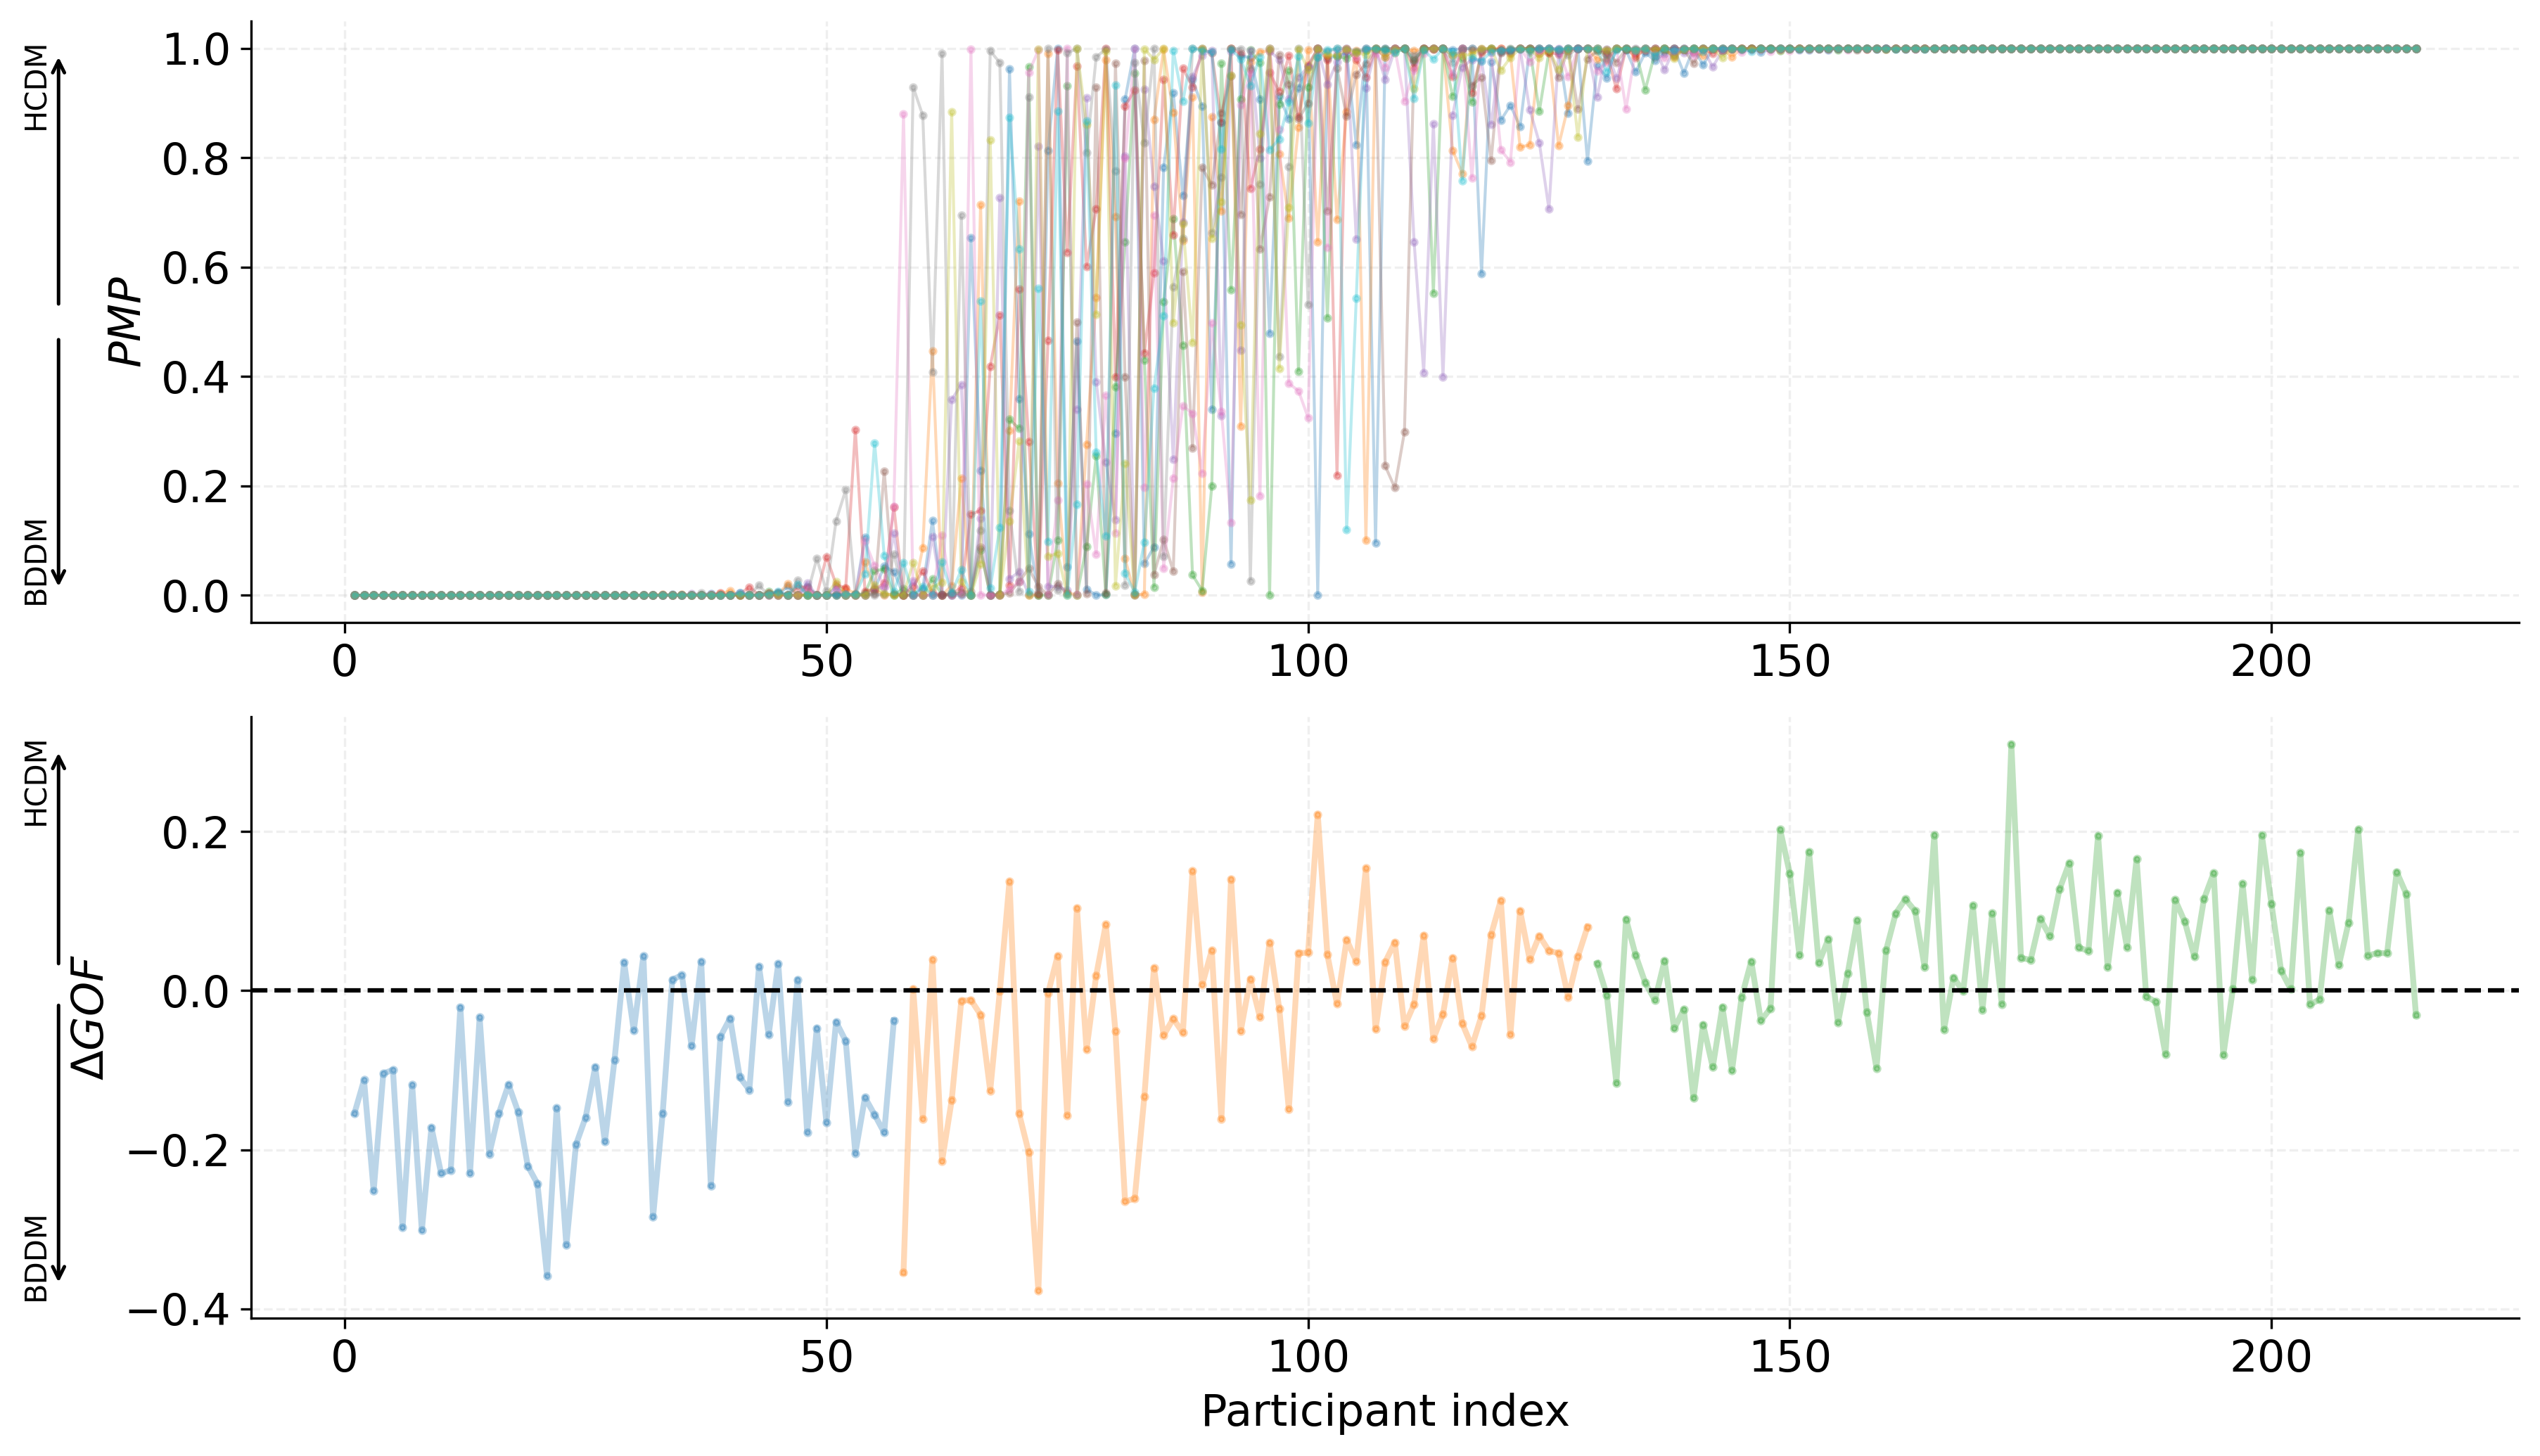

In [27]:
figure, ax = plt.subplots(2, 1, figsize=(12, 7), dpi = 300)
for i in range(10):
    ax[0].plot(np.arange(1,216,1), sorted_prediction[i, : ,0], alpha = 0.3, lw = 1, marker = ".", markersize = 4)
ax[0].set_ylabel(r'$PMP$', fontsize=15)
ax[0].tick_params(axis = 'both', labelsize = 15)
ax[0].grid(alpha=0.2, linestyle="--")
ax[0].annotate('', xy=(-0.085, 0.95), xytext=(-0.085, 0.52),
               xycoords='axes fraction', textcoords='axes fraction',
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax[0].annotate('', xy=(-0.085, 0.05), xytext=(-0.085, 0.48),
               xycoords='axes fraction', textcoords='axes fraction',
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax[0].text(-0.095, 0.97, 'HCDM', transform=ax[0].transAxes,
           fontsize=10, va='top', ha='center', rotation=90)
ax[0].text(-0.095, 0.03, 'BDDM', transform=ax[0].transAxes,
           fontsize=10, va='bottom', ha='center', rotation=90)

ax[1].plot(np.arange(1,58,1), sorted_gof_bddm[0:57] - sorted_gof_hcdm[0:57], alpha = 0.3, lw = 2, marker = ".", markersize = 4)
ax[1].plot(np.arange(58,130,1), sorted_gof_bddm[57:129] - sorted_gof_hcdm[57:129], alpha = 0.3, lw = 2, marker = ".", markersize = 4)
ax[1].plot(np.arange(130,216,1), sorted_gof_bddm[129:215] - sorted_gof_hcdm[129:215], alpha = 0.3, lw = 2, marker = ".", markersize = 4)
ax[1].set_ylabel(r'$\Delta GOF$', fontsize=15)
ax[1].tick_params(axis = 'both', labelsize = 15)
ax[1].set_xlabel("Participant index", fontsize=15)
ax[1].grid(alpha=0.2, linestyle="--")

ax[1].axhline(0, color='black', ls ='--')
ax[1].annotate('', xy=(-0.085, 0.95), xytext=(-0.085, 0.58),
               xycoords='axes fraction', textcoords='axes fraction',
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax[1].annotate('', xy=(-0.085, 0.05), xytext=(-0.085, 0.53),
               xycoords='axes fraction', textcoords='axes fraction',
               arrowprops=dict(arrowstyle='->', color='black', lw=1.2))
ax[1].text(-0.095, 0.97, 'HCDM', transform=ax[1].transAxes,
           fontsize=10, va='top', ha='center', rotation=90)
ax[1].text(-0.095, 0.03, 'BDDM', transform=ax[1].transAxes,
           fontsize=10, va='bottom', ha='center', rotation=90)
# clean spines
for spine in ["top", "right"]:
    ax[0].spines[spine].set_visible(False)
    ax[1].spines[spine].set_visible(False)

# tight layout
plt.tight_layout()
plt.savefig('../plots/model_comparison.pdf', bbox_inches='tight')
plt.show()

    

### Who get mixed results and why?

In [26]:
mixed_par = np.where(np.std(prediction[:,:,0], axis = 0)>0.25)
mixed_par 

(array([  2,   7,  13,  17,  18,  20,  21,  29,  32,  36,  47,  50,  54,
         57,  59,  64,  66,  67,  69,  75,  80,  90,  93,  94, 108, 117,
        120, 121, 127, 134, 138, 139, 141, 143, 148, 150, 153, 157, 160,
        164, 170, 172, 173, 176, 188, 192, 197, 198, 200, 206, 212, 214]),)

In [27]:
reversal_par = np.where((np.max(prediction[:,:,0], axis = 0) - np.min(prediction[:,:,0], axis = 0))>0.9)
reversal_par

(array([  2,   7,  13,  17,  20,  21,  29,  32,  36,  47,  54,  57,  59,
         64,  66,  67,  69,  75,  80,  90,  93, 108, 117, 120, 121, 127,
        134, 138, 139, 141, 143, 148, 150, 157, 160, 164, 170, 172, 176,
        188, 192, 197, 198, 200, 212, 214]),)

In [28]:
ABMC_par = np.intersect1d(mixed_par, reversal_par)
%store ABMC_par

Stored 'ABMC_par' (ndarray)


In [29]:
bddm_par = np.where(np.mean(prediction[:,:,0], axis = 0)<0.01)
%store bddm_par 

Stored 'bddm_par' (tuple)


In [30]:
hcdm_par = np.where(np.mean(prediction[:,:,0], axis = 0)>0.99)
%store hcdm_par 

Stored 'hcdm_par' (tuple)


In [31]:
participant_fav_hcdm = np.where(np.mean(prediction[:,:,0], axis = 0)>0.90)
participant_fav_bddm = np.where(np.mean(prediction[:,:,0], axis = 0)<0.10)

In [32]:
# Sample Data
std_response_bddm = np.zeros((participant_fav_bddm[0].shape[0],4))
std_response_hcdm = np.zeros((participant_fav_hcdm[0].shape[0],4))
p = 0
for n in participant_fav_bddm[0]:
    for i in range(4):
        mask = np.where(data_re["con"][n,:,i] != 0)
        resp = data_re["resp"][n,:][mask]
        std_response_bddm[p,i] = np.std(resp)
    p = p + 1

p = 0
for n in participant_fav_hcdm[0]:
    for i in range(4):
        mask = np.where(data_re["con"][n,:,i] != 0)
        resp = data_re["resp"][n,:][mask]
        std_response_hcdm[p,i] = np.std(resp)
    p = p + 1




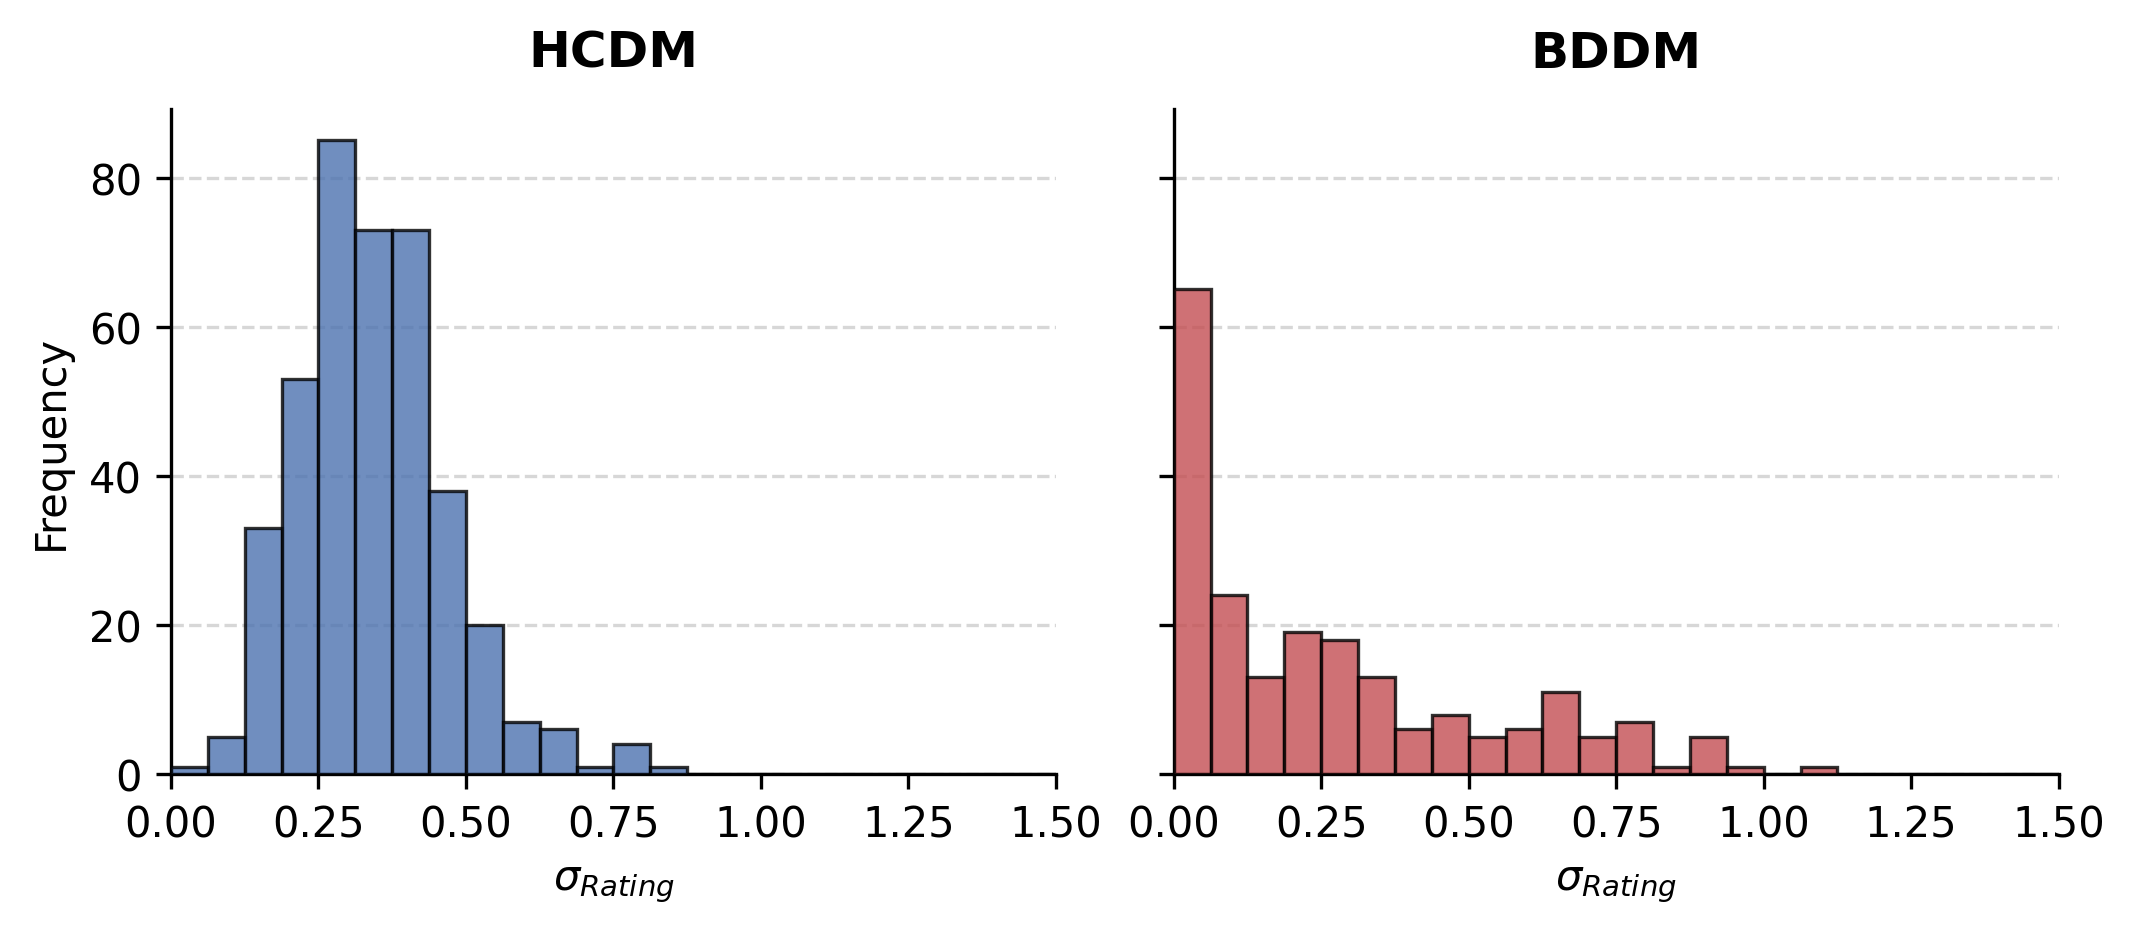

In [33]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Define consistent bins for fair comparison
# Using linspace ensures both plots share the exact same bin width and edges
bins = np.linspace(0, 1.5, 25) 

# 2. Setup Figure with sharey=True
# sharey=True forces the Y-axis to be identical, allowing direct visual comparison of height
fig, ax = plt.subplots(1, 2, figsize=(7, 3), dpi=300, sharey=True, constrained_layout=True)

# 3. Plotting with styling
# alpha: transparency; edgecolor: distinct bar separation; zorder: puts bars above grid
kwargs = dict(bins=bins, alpha=0.8, edgecolor='black', linewidth=0.8, zorder=3)

ax[0].hist(std_response_hcdm.flatten(), color='#4C72B0', **kwargs)
ax[1].hist(std_response_bddm.flatten(), color='#C44E52', **kwargs)

# 4. Loop to apply common styling to both axes
titles = ['HCDM', 'BDDM']
for i, axis in enumerate(ax):
    # Set limits
    axis.set_xlim(0, 1.5)
    
    # Add grid (behind the bars)
    axis.grid(axis='y', linestyle='--', alpha=0.5, zorder=0)
    
    # Remove top and right spines (Tufte's "chart junk" principle)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    
    # Titles and Labels
    axis.set_title(titles[i], fontsize=12, fontweight='bold', pad=10)
    axis.set_xlabel(r'$\sigma_{Rating}$', fontsize=10)
    
    # Add panel labels (A, B) - Standard in publications
    #axis.text(-0.1, 1.1, ["A", "B"][i], transform=axis.transAxes, 
    #          size=16, weight='bold')

# Only set Y-label on the first plot to reduce clutter
ax[0].set_ylabel("Frequency", fontsize=10)

# 5. Saving
# bbox_inches='tight' prevents labels from getting cut off
plt.savefig('../plots/std_model_comparison.pdf', bbox_inches='tight')
plt.show()